In [1]:
import os, sys

# Root project
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to sys.path:", project_root)

Project root added to sys.path: /Users/charithapalika/Desktop/Lab projects/Labsystem/Rossler/ROSSLER_CLEANED_FILES


In [2]:
from stn_gpe import *
from scipy.integrate import solve_ivp
from scipy import signal
import numpy as np
from matplotlib import pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator
import os
from tqdm.autonotebook import tqdm

import pickle as pkl

/Users/charithapalika/Desktop/Lab projects/Labsystem/Rossler/ROSSLER_CLEANED_FILES/stn_gpe/analysis.py:8: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [3]:
path = os.path.join(project_root,'params/stn_gpe_params/params_I_ext.yaml') 
data = load_yaml(path)
omega =np.ones((data['N'],1))*data['omega']  

## Bifurcation

In [4]:
I_ext_arr = np.linspace(0,1.8,500)
N = data['N']
a = data['a']
b = data['b']
c = data['c']
d = data['d']
k = data['k']

  0%|          | 0/500 [00:00<?, ?it/s]

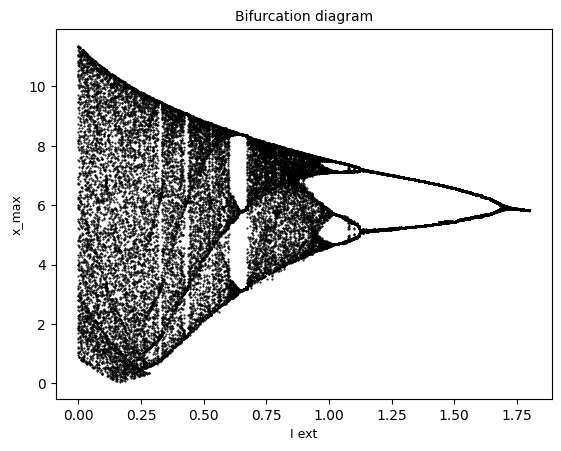

In [ ]:
bifurcation_data = {}
corr_coeff_data = {}
std_data = {}

for Iext in tqdm(I_ext_arr): 
    RN = RosslerNetwork(N = N, a = a,
                    b = b, c = c, 
                    d = d, k = k,
                    omega= omega, 
                    Iext=Iext)
    sol = RN.run()


    # Bifurcation 
    x_data = np.array(sol.y)[0,500000:2*500000] #taking x values of first rossler
    x_peaks_timepoints, _ = signal.find_peaks(x_data) #removing transient
    x_peak_vals = x_data[x_peaks_timepoints]
    bifurcation_data[Iext] = x_peak_vals
    x_ax = Iext * np.ones(x_peak_vals.shape[0])
    plt.plot(x_ax,x_peak_vals,'.', color = 'black', markersize = 1)

    # x_values of all oscillators
    x_vals = np.array(sol.y)[0:data['N'],500000:500000*2]    
    # corr coeff
    corr = np.corrcoef((x_vals))
    avg_corr = np.mean(corr[np.triu_indices(4, k = 1)])
    corr_coeff_data[Iext] = avg_corr

    #std deviation
    normalized_x_vals = (x_vals - np.min(x_vals))/(np.max(x_vals)-np.min(x_vals))
    x_mean = np.mean(normalized_x_vals,0)
    x_std = np.std(normalized_x_vals,0)
    std_data[Iext] = np.mean(x_std)

plt.xlabel('I ext', fontsize = 9)
plt.ylabel('x_max', fontsize = 9)
plt.title('Bifurcation diagram', fontsize = 10)

plt.show()

## Saving data

In [ ]:
data = {'bifurcation': bifurcation_data,
        'corrcoeff': corr_coeff_data,
        'variance': std_data}

In [ ]:
# save dictionary as pickle
folder_name = 'temp/I_ext'
folder_path = project_root + '/' + folder_name
# create a temp folder in root base folder
os.makedirs(folder_path, exist_ok=True)


file_name = 'I_ext_bifurcation'
with open(folder_path + '/' + file_name + '.pkl', 'wb') as handle:
    pkl.dump(data, handle)

print("Pickle file saved successfully.")

## Reading bifurcation data

In [ ]:
# read pickle file
import pickle
import numpy as np
from matplotlib import pyplot as plt
with open(folder_path + '/' + file_name + '.pkl', "rb") as file:
    data = pickle.load(file)


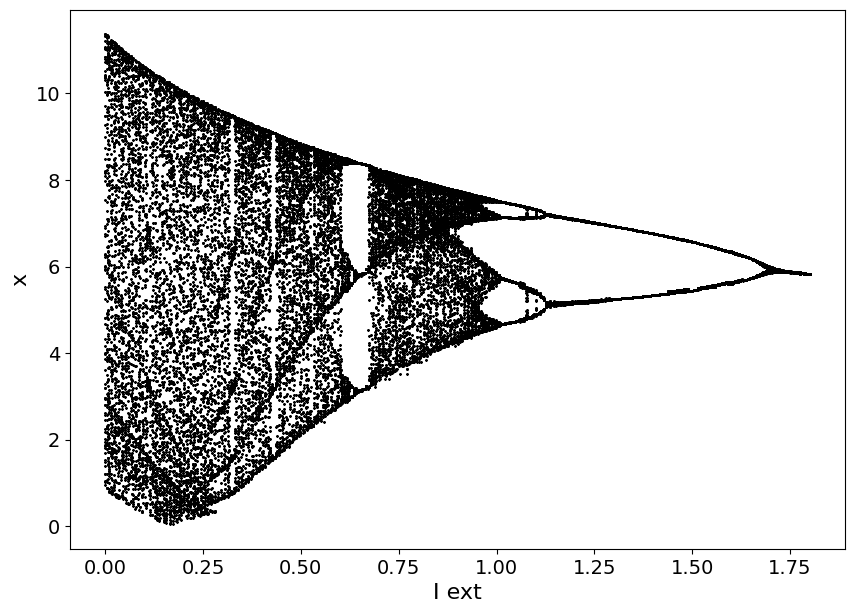

<Figure size 640x480 with 0 Axes>

In [ ]:
I_ext_arr = np.linspace(0,1.8,500)
bifurcation_data = data['bifurcation']
plt.figure(figsize=(10,7))
for I_ext in I_ext_arr:
    x_peak_vals = bifurcation_data[I_ext]
    x_ax = I_ext * np.ones(x_peak_vals.shape[0])
    plt.plot(x_ax,x_peak_vals,'*', color = 'black', markersize = 1.5)

plt.xlabel('I ext', fontsize = 16, fontweight = 530)
plt.ylabel('x', fontsize = 16, fontweight = 530)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()
plt.tight_layout()